# Análisis Exploratorio de Datos (EDA)
## Stack Overflow Developer Survey 2025

**Dataset:** Stack Overflow Annual Developer Survey 2025
**Fuente:** https://survey.stackoverflow.co/ - https://github.com/StackExchange/Survey/blob/main/packages/archive/2025/results.csv
**Filas:** ~49.000 respuestas  |  **Columnas seleccionadas:** 13

---

## 0. Importación de librerías

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Configuración global de visualizaciones
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"]      = 12

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


---
## 1. Selección y carga del dataset

El dataset proviene de la encuesta anual de Stack Overflow 2025, respondida por
~89 000 desarrolladores de todo el mundo. Contiene información sobre salarios,
experiencia, educación, modalidad de trabajo y herramientas utilizadas.

> **Instrucción:** colocar `stackoverflow_results_2025.csv` en el mismo directorio que este notebook.

In [56]:
# ── Carga ──────────────────────────────────────────────────────────────────
df_raw = pd.read_csv("stackoverflow_results_2025.csv")

print(f"Shape del dataset original : {df_raw.shape}")
print(f"  Filas   : {df_raw.shape[0]:,}")
print(f"  Columnas: {df_raw.shape[1]}")
df_raw.head(3)

Shape del dataset original : (49191, 172)
  Filas   : 49,191
  Columnas: 172


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0


In [57]:
# ── Selección de columnas relevantes ───────────────────────────────────────
COLS = [
    "ResponseId",           # Identificador único
    "Age",                  # Rango etario del respondente
    "Country",              # País de residencia
    "EdLevel",              # Nivel educativo más alto alcanzado
    "Employment",           # Situación laboral (puede ser multi-valor)
    "RemoteWork",           # Modalidad de trabajo
    "YearsCode",         # Años de experiencia profesional programando
    "WorkExp",              # Años de experiencia laboral total
    "ConvertedCompYearly",  # Salario anual en USD (normalizado por PPP)
    "DevType",              # Tipo de desarrollador (puede ser multi-valor)
    "OrgSize",              # Tamaño de la organización
    "JobSat",               # Satisfacción laboral
    "AISelect",             # Uso de herramientas de IA en el trabajo
]

df = df_raw[COLS].copy()
print(f"Shape tras selección de columnas: {df.shape}")
df.dtypes

Shape tras selección de columnas: (49191, 13)


ResponseId               int64
Age                        str
Country                    str
EdLevel                    str
Employment                 str
RemoteWork                 str
YearsCode              float64
WorkExp                float64
ConvertedCompYearly    float64
DevType                    str
OrgSize                    str
JobSat                 float64
AISelect                   str
dtype: object

---
## 2. Hipótesis planteadas

A partir del contexto del dataset se formularon las siguientes cinco hipótesis:

| # | Hipótesis |
|---|-----------|
| H1 | Los desarrolladores con **más años de experiencia profesional** tienen salarios significativamente más altos. |
| H2 | El trabajo **remoto** está asociado a salarios más altos que el trabajo presencial. |
| H3 | El **nivel educativo formal** influye positivamente en el salario. |
| H4 | Los desarrolladores en **empresas más grandes** ganan más que los de empresas pequeñas. |
| H5 | Existen **diferencias salariales significativas** según el tipo de desarrollador (DevType). |

---
## 3. Limpieza y preparación de datos

### 3.1 Valores nulos

In [58]:
nulos   = df.isnull().sum()
pct     = (nulos / len(df) * 100).round(2)
resumen = pd.DataFrame({"Nulos": nulos, "Porcentaje (%)": pct})
resumen = resumen[resumen["Nulos"] > 0].sort_values("Porcentaje (%)", ascending=False)

print("Columnas con valores nulos:")
resumen

Columnas con valores nulos:


,Nulos,Porcentaje (%)
ConvertedCompYearly,25244,51.32
JobSat,22521,45.78
AISelect,15471,31.45
RemoteWork,15411,31.33
OrgSize,15013,30.52
Country,13754,27.96
WorkExp,6298,12.80
YearsCode,6149,12.50
DevType,5511,11.20
EdLevel,1042,2.12


**Interpretación:**
- `ConvertedCompYearly` tiene alto % de nulos porque muchos encuestados no reportan
  su salario (desempleados, estudiantes, o quienes prefieren no revelar ingresos).
  Se trabajará con un subconjunto `df_sal` únicamente para los análisis salariales.
- `RemoteWork`, `OrgSize` y `DevType` tienen nulos moderados; se omitirán puntualmente
  en los gráficos que los requieran.

### 3.2 Duplicados

In [59]:
n_dup = df.duplicated().sum()
print(f"Filas duplicadas: {n_dup}")
# Cada fila corresponde a una respuesta única identificada por ResponseId
print(f"ResponseId únicos: {df['ResponseId'].nunique():,}  (= total filas → sin duplicados)")

Filas duplicadas: 0
ResponseId únicos: 49,191  (= total filas → sin duplicados)


### 3.3 Conversión de experiencia a numérico

In [60]:
def limpiar_anios(valor):
    """Convierte strings de años de experiencia al tipo float.

    Casos especiales del dataset:
        'Less than 1 year'  -> 0.5
        'More than 50 years' -> 50.0
    """
    if pd.isna(valor):
        return np.nan
    if valor == "Less than 1 year":
        return 0.5
    if valor == "More than 50 years":
        return 50.0
    try:
        return float(valor)
    except ValueError:
        return np.nan

df["YearsCode"] = df["YearsCode"].apply(limpiar_anios)
df["WorkExp"]      = df["WorkExp"].apply(limpiar_anios)

print("YearsCode — estadísticas tras limpieza:")
print(df["YearsCode"].describe().apply(lambda x: f"{x:.2f}"))
print()
print("WorkExp — estadísticas tras limpieza:")
print(df["WorkExp"].describe().apply(lambda x: f"{x:.2f}"))

YearsCode — estadísticas tras limpieza:
count    43042.00
mean        16.57
std         11.79
min          1.00
25%          8.00
50%         14.00
75%         24.00
max        100.00
Name: YearsCode, dtype: str

WorkExp — estadísticas tras limpieza:
count    42893.00
mean        13.37
std         10.80
min          1.00
25%          5.00
50%         10.00
75%         20.00
max        100.00
Name: WorkExp, dtype: str


### 3.4 Simplificación de DevType (campo multi-valor)

In [61]:
def simplificar_devtype(valor):
    """Asigna un único rol principal a partir de la cadena multi-valor de DevType."""
    if pd.isna(valor):
        return np.nan
    v = valor.lower()
    if "data scientist" in v or "machine learning" in v:
        return "Data Scientist / ML"
    if "data" in v and "analyst" in v:
        return "Data Analyst"
    if "full-stack" in v:
        return "Full-stack Developer"
    if "back-end" in v:
        return "Back-end Developer"
    if "front-end" in v:
        return "Front-end Developer"
    if "devops" in v or "site reliability" in v:
        return "DevOps / SRE"
    if "mobile" in v:
        return "Mobile Developer"
    if "embedded" in v:
        return "Embedded Developer"
    if "game" in v:
        return "Game Developer"
    if "security" in v:
        return "Security Engineer"
    if "engineering manager" in v:
        return "Engineering Manager"
    if "student" in v:
        return "Student"
    return "Other"

df["DevType_simp"] = df["DevType"].apply(simplificar_devtype)
print("Distribución de roles simplificados:")
print(df["DevType_simp"].value_counts().to_string())

Distribución de roles simplificados:
DevType_simp
Other                   13362
Full-stack Developer    12351
Back-end Developer       6453
Student                  3008
Front-end Developer      1974
Mobile Developer         1391
Embedded Developer       1274
Engineering Manager      1068
DevOps / SRE             1053
Data Scientist / ML       574
Game Developer            451
Security Engineer         370
Data Analyst              351


### 3.5 Etiquetas cortas para EdLevel y OrgSize

In [62]:
# ── EdLevel ─────────────────────────────────────────────────────────────────
EDLEVEL_MAP = {
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)": "Licenciatura",
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)": "Maestría",
    "Some college/university study without earning a degree": "Univ. sin título",
    "Associate degree (A.A., A.S., etc.)": "Tecnicatura",
    "Primary/elementary school": "Primaria",
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": "Secundaria",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": "Doctorado / PhD",
    "Something else": "Otro",
}
df["EdLevel_short"] = df["EdLevel"].map(EDLEVEL_MAP).fillna(df["EdLevel"])

# Orden lógico (de menor a mayor nivel educativo)
EDLEVEL_ORDER = [
    "Primaria", "Secundaria", "Univ. sin título",
    "Tecnicatura", "Licenciatura", "Maestría", "Doctorado / PhD",
]

# ── OrgSize ──────────────────────────────────────────────────────────────────
ORGSIZE_MAP = {
    "Just me - I am a one-man shop":"Solo",
    "2 to 9 employees":"2-9",
    "10 to 19 employees":"10-19",
    "20 to 99 employees":"20-99",
    "100 to 499 employees":"100-499",
    "500 to 999 employees":"500-999",
    "1,000 to 4,999 employees":"1K-5K",
    "5,000 to 9,999 employees":"5K-10K",
    "10,000 or more employees":"+10K",
    "I don't know":"No sabe",
}
ORGSIZE_ORDER = ["Solo","2-9","10-19","20-99","100-499","500-999","1K-5K","5K-10K","+10K"]

df["OrgSize_short"] = df["OrgSize"].map(ORGSIZE_MAP).fillna(df["OrgSize"])
df["OrgSize_short"] = pd.Categorical(df["OrgSize_short"], categories=ORGSIZE_ORDER, ordered=True)

print("EdLevel_short — valores únicos:")
print(df["EdLevel_short"].value_counts().to_string())

EdLevel_short — valores únicos:
EdLevel_short
Licenciatura               20278
Maestría                   12589
Univ. sin título            6182
Secundaria                  3631
Doctorado / PhD             2624
Tecnicatura                 1562
Other (please specify):      701
Primaria                     582


### 3.6 Subconjunto salarial — df_sal

In [63]:
# Nos quedamos solo con respuestas que tienen salario reportado y razonable
df_sal = df[df["ConvertedCompYearly"].notna()].copy()
df_sal = df_sal[df_sal["ConvertedCompYearly"] > 1_000]       # Descartamos salarios casi nulos

# Recortamos el 1 % superior para evitar outliers extremos en visualizaciones
p99 = df_sal["ConvertedCompYearly"].quantile(0.99)
df_sal = df_sal[df_sal["ConvertedCompYearly"] <= p99]

print(f"Filas con sueldo válido : {len(df_sal):,}")
print(f"Sueldo mínimo  : USD {df_sal['ConvertedCompYearly'].min():>12,.0f}")
print(f"Sueldo mediano : USD {df_sal['ConvertedCompYearly'].median():>12,.0f}")
print(f"Sueldo medio   : USD {df_sal['ConvertedCompYearly'].mean():>12,.0f}")
print(f"Sueldo máximo  : USD {df_sal['ConvertedCompYearly'].max():>12,.0f}")
print(f"\nUmbral 99 %     : USD {p99:>12,.0f}  (filas eliminadas como outliers extremos)")

Filas con sueldo válido : 22,981
Sueldo mínimo  : USD        1,007
Sueldo mediano : USD       76,412
Sueldo medio   : USD       90,357
Sueldo máximo  : USD      450,000

Umbral 99 %     : USD      450,000  (filas eliminadas como outliers extremos)


### 3.7 Resumen del dataset limpio

In [64]:
print("=== Dataset completo (df) ===")
print(f"  Shape : {df.shape}")
print()
print("Tipos de datos finales:")
print(df.dtypes)
print()
print("=== Subconjunto salarial (df_sal) ===")
print(f"  Shape : {df_sal.shape}")

=== Dataset completo (df) ===
  Shape : (49191, 16)

Tipos de datos finales:
ResponseId                int64
Age                         str
Country                     str
EdLevel                     str
Employment                  str
RemoteWork                  str
YearsCode               float64
WorkExp                 float64
ConvertedCompYearly     float64
DevType                     str
OrgSize                     str
JobSat                  float64
AISelect                    str
DevType_simp                str
EdLevel_short               str
OrgSize_short          category
dtype: object

=== Subconjunto salarial (df_sal) ===
  Shape : (22981, 16)


---
## 4. Análisis Exploratorio de Datos (EDA)

### 4.1 Tipos de variables y estadísticas descriptivas

In [65]:
print("── Variables NUMÉRICAS ──────────────────────────────────────")
cols_num = ["ConvertedCompYearly", "YearsCode", "WorkExp"]
df_sal[cols_num].describe().T.style.format("{:.2f}")

── Variables NUMÉRICAS ──────────────────────────────────────


,count,mean,std,min,25%,50%,75%,max
ConvertedCompYearly,22981.00,90356.95,69316.97,1007.00,41765.00,76412.00,121000.00,450000.00
YearsCode,22891.00,17.84,10.91,1.00,10.00,15.00,25.00,100.00
WorkExp,22576.00,13.74,10.01,1.00,6.00,11.00,20.00,100.00


In [66]:
print("── Variables CATEGÓRICAS (top valores) ─────────────────────")
for col in ["RemoteWork", "EdLevel_short", "DevType_simp", "OrgSize_short", "AISelect"]:
    print(f"\n{col}:")
    print(df[col].value_counts().head(5).to_string())

── Variables CATEGÓRICAS (top valores) ─────────────────────

RemoteWork:
RemoteWork
Remote                                                                          10931
Hybrid (some remote, leans heavy to in-person)                                   6732
In-person                                                                        6042
Hybrid (some in-person, leans heavy to flexibility)                              5831
Your choice (very flexible, you can come in when you want or just as needed)     4244

EdLevel_short:
EdLevel_short
Licenciatura        20278
Maestría            12589
Univ. sin título     6182
Secundaria           3631
Doctorado / PhD      2624

DevType_simp:
DevType_simp
Other                   13362
Full-stack Developer    12351
Back-end Developer       6453
Student                  3008
Front-end Developer      1974

OrgSize_short:
OrgSize_short
20-99      6688
100-499    6109
+10K       4965
1K-5K      4156
500-999    2361

AISelect:
AISelect
Yes, I use AI too

---
### 4.2 Distribuciones — Histogramas con KDE

> Se grafican las tres variables numéricas continuas principales.

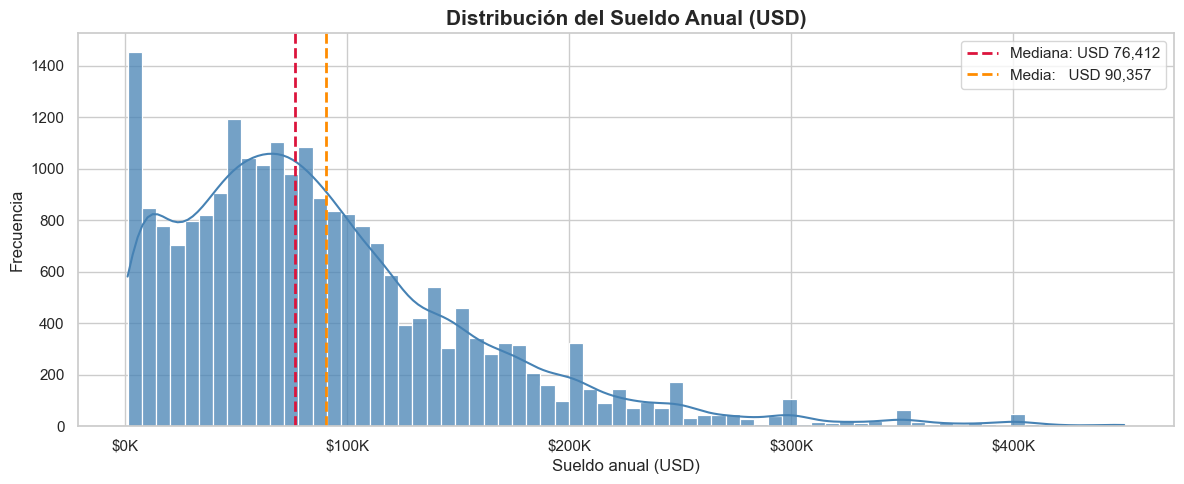

Asimetría (skewness): 1.41
→ Distribución asimétrica positiva: la mayoría gana menos que la media.
  Los salarios muy altos 'tiran' la media hacia arriba.


In [67]:
# ── Histograma 1: Sueldo anual (USD) ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(
    data=df_sal, x="ConvertedCompYearly",
    bins=70, kde=True, color="steelblue", alpha=0.75, ax=ax
)

mediana = df_sal["ConvertedCompYearly"].median()
media   = df_sal["ConvertedCompYearly"].mean()
ax.axvline(mediana, color="crimson",     ls="--", lw=2, label=f"Mediana: USD {mediana:,.0f}")
ax.axvline(media,   color="darkorange",  ls="--", lw=2, label=f"Media:   USD {media:,.0f}")

ax.set_title("Distribución del Sueldo Anual (USD)", fontsize=15, fontweight="bold")
ax.set_xlabel("Sueldo anual (USD)")
ax.set_ylabel("Frecuencia")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${ x/1000:.0f}K"))
ax.legend()
plt.tight_layout()
plt.savefig("hist_salario.png", dpi=150, bbox_inches="tight")
plt.show()

skew = df_sal["ConvertedCompYearly"].skew()
print(f"Asimetría (skewness): {skew:.2f}")
print("→ Distribución asimétrica positiva: la mayoría gana menos que la media.")
print("  Los salarios muy altos 'tiran' la media hacia arriba.")

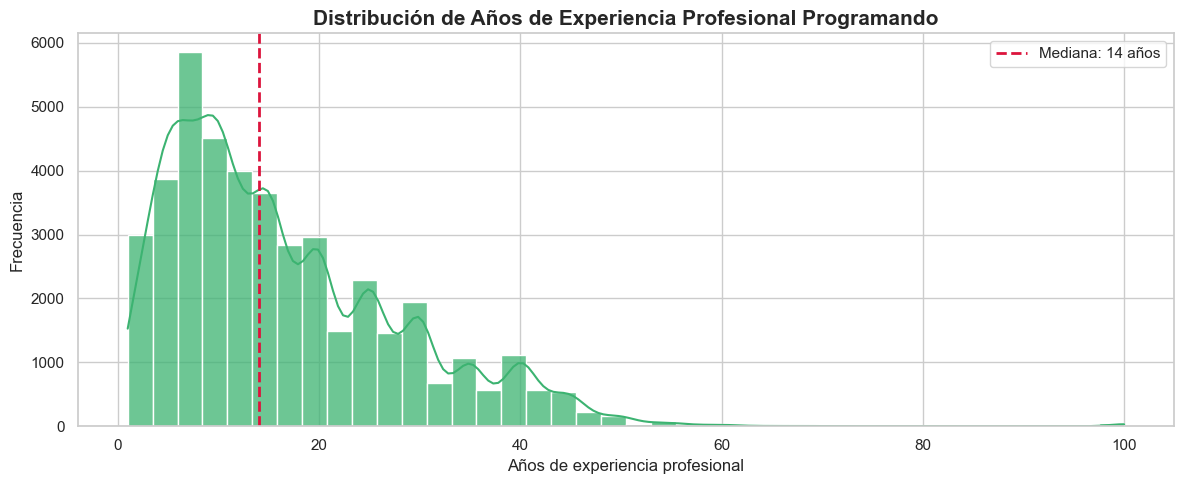

Mediana: 14.0 años  |  Media: 16.6 años
Asimetría: 1.24  → sesgo positivo: la mayoría tiene menos de 10 años de experiencia.


In [68]:
# ── Histograma 2: Años de experiencia profesional ────────────────────────────
df_exp = df.dropna(subset=["YearsCode"])

fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(
    data=df_exp, x="YearsCode",
    bins=40, kde=True, color="mediumseagreen", alpha=0.75, ax=ax
)

med_exp = df_exp["YearsCode"].median()
ax.axvline(med_exp, color="crimson", ls="--", lw=2, label=f"Mediana: {med_exp:.0f} años")

ax.set_title("Distribución de Años de Experiencia Profesional Programando", fontsize=15, fontweight="bold")
ax.set_xlabel("Años de experiencia profesional")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.savefig("hist_exp_pro.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mediana: {med_exp:.1f} años  |  Media: {df_exp['YearsCode'].mean():.1f} años")
print(f"Asimetría: {df_exp['YearsCode'].skew():.2f}  → sesgo positivo: la mayoría tiene menos de 10 años de experiencia.")

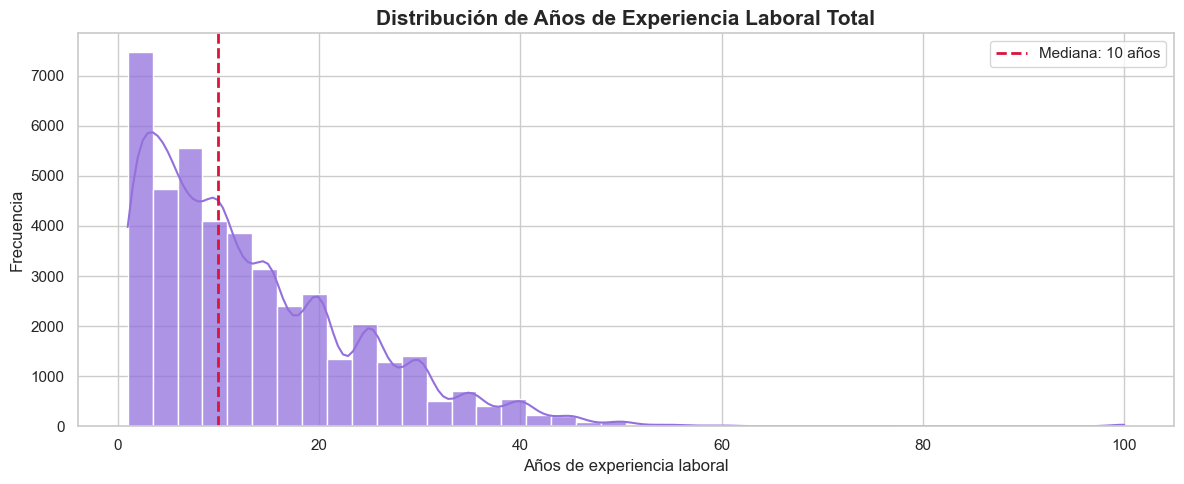

Mediana: 10.0 años  |  Media: 13.4 años


In [69]:
# ── Histograma 3: Años de experiencia laboral total ──────────────────────────
df_wexp = df.dropna(subset=["WorkExp"])

fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(
    data=df_wexp, x="WorkExp",
    bins=40, kde=True, color="mediumpurple", alpha=0.75, ax=ax
)

med_wexp = df_wexp["WorkExp"].median()
ax.axvline(med_wexp, color="crimson", ls="--", lw=2, label=f"Mediana: {med_wexp:.0f} años")

ax.set_title("Distribución de Años de Experiencia Laboral Total", fontsize=15, fontweight="bold")
ax.set_xlabel("Años de experiencia laboral")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.savefig("hist_exp_laboral.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mediana: {med_wexp:.1f} años  |  Media: {df_wexp['WorkExp'].mean():.1f} años")

---
### 4.3 Valores atípicos — Boxplots

> Los boxplots se construyen **sin flyers** (outliers no se grafican) para mejorar
  la legibilidad, pero los valores atípicos sí son reportados numéricamente.

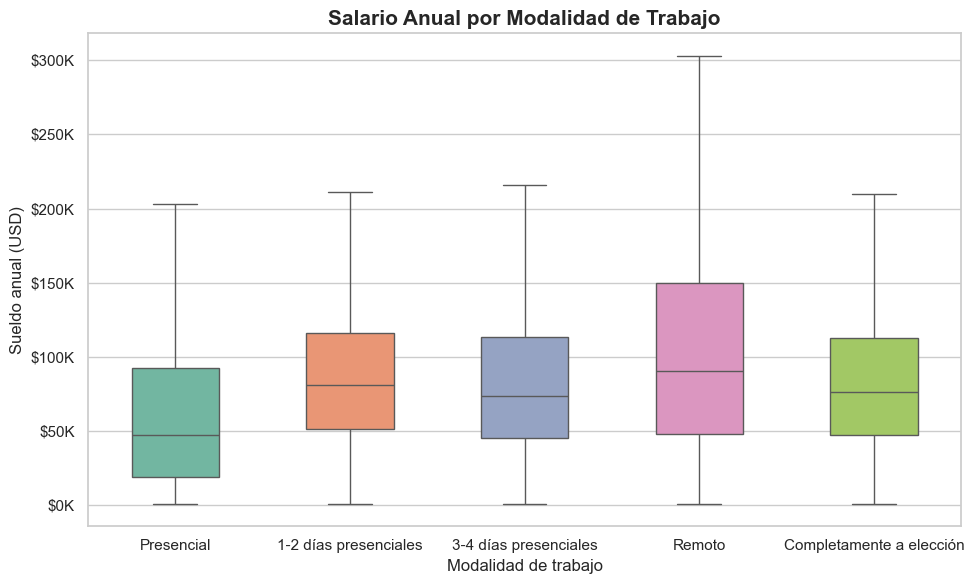

                             Mediana        Media     n
Modalidad                                              
Presencial                USD 47,566   USD 66,614  3053
1-2 días presenciales     USD 81,210   USD 90,619  3734
3-4 días presenciales     USD 73,375   USD 87,649  4078
Remoto                    USD 90,491  USD 104,595  6837
Completamente a elección  USD 76,570   USD 87,922  2665


In [70]:
# ── Boxplot 1: Sueldo por modalidad de trabajo ───────────────────────────────
REMOTE_ORDER  = ["In-person", "Hybrid (some in-person, leans heavy to flexibility)", "Hybrid (some remote, leans heavy to in-person)", "Remote", "Your choice (very flexible, you can come in when you want or just as needed)"]
REMOTE_LABELS = {"In-person": "Presencial",
                 "Hybrid (some in-person, leans heavy to flexibility)": "1-2 días presenciales",
                 "Hybrid (some remote, leans heavy to in-person)": "3-4 días presenciales",
                 "Remote": "Remoto",
                 "Your choice (very flexible, you can come in when you want or just as needed)": "Completamente a elección"}

df_bp1 = df_sal[df_sal["RemoteWork"].isin(REMOTE_ORDER)].copy()
df_bp1["Modalidad"] = df_bp1["RemoteWork"].map(REMOTE_LABELS)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df_bp1, x="Modalidad", y="ConvertedCompYearly",
    order=["Presencial", "1-2 días presenciales", "3-4 días presenciales", "Remoto", "Completamente a elección"],
    palette="Set2", showfliers=False, width=0.5, ax=ax
)

ax.set_title("Salario Anual por Modalidad de Trabajo", fontsize=15, fontweight="bold")
ax.set_xlabel("Modalidad de trabajo")
ax.set_ylabel("Sueldo anual (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
plt.tight_layout()
plt.savefig("box_remotework.png", dpi=150, bbox_inches="tight")
plt.show()

stats_bp1 = df_bp1.groupby("Modalidad")["ConvertedCompYearly"].agg(
    Mediana="median", Media="mean", n="count"
).loc[["Presencial", "1-2 días presenciales", "3-4 días presenciales", "Remoto", "Completamente a elección"]]
stats_bp1["Mediana"] = stats_bp1["Mediana"].apply(lambda x: f"USD {x:,.0f}")
stats_bp1["Media"]   = stats_bp1["Media"].apply(lambda x: f"USD {x:,.0f}")
print(stats_bp1.to_string())

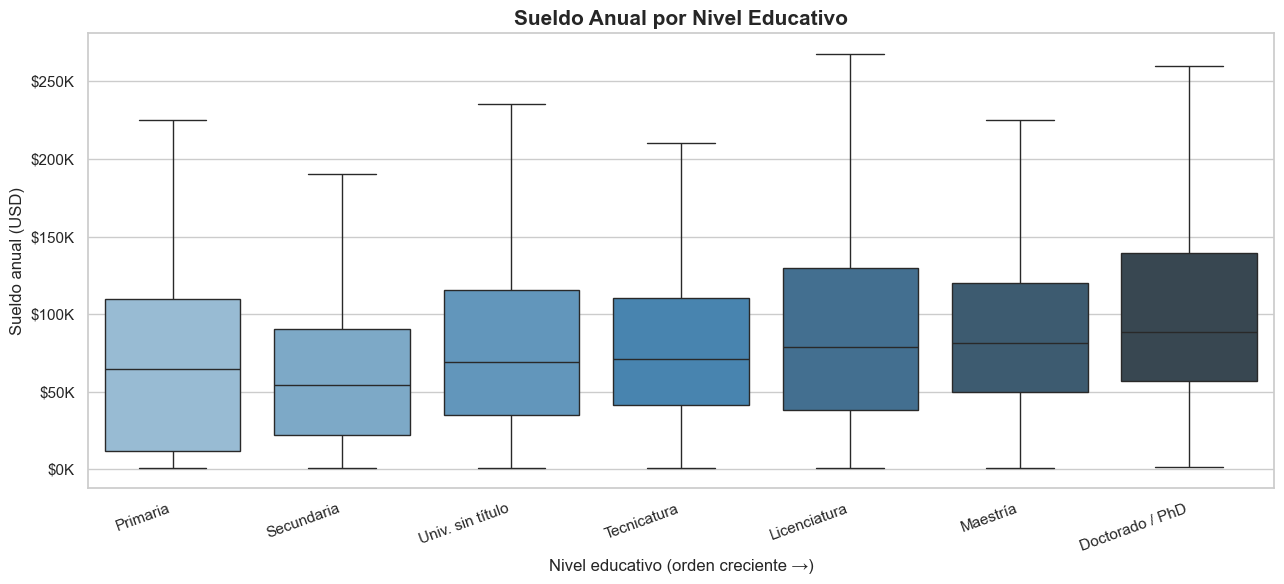

Salario mediano por nivel educativo:
EdLevel_short
Primaria            USD 64,408
Secundaria          USD 54,527
Univ. sin título    USD 69,310
Tecnicatura         USD 70,769
Licenciatura        USD 78,714
Maestría            USD 81,210
Doctorado / PhD     USD 88,171


In [71]:
# ── Boxplot 2: Sueldo por nivel educativo ────────────────────────────────────
df_bp2 = df_sal[df_sal["EdLevel_short"].isin(EDLEVEL_ORDER)].copy()

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(
    data=df_bp2, x="EdLevel_short", y="ConvertedCompYearly",
    order=EDLEVEL_ORDER, palette="Blues_d", showfliers=False, ax=ax
)

ax.set_title("Sueldo Anual por Nivel Educativo", fontsize=15, fontweight="bold")
ax.set_xlabel("Nivel educativo (orden creciente →)")
ax.set_ylabel("Sueldo anual (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("box_edlevel.png", dpi=150, bbox_inches="tight")
plt.show()

stats_bp2 = df_bp2.groupby("EdLevel_short", observed=True)["ConvertedCompYearly"].median()
stats_bp2 = stats_bp2.reindex(EDLEVEL_ORDER)
stats_bp2 = stats_bp2.apply(lambda x: f"USD {x:,.0f}" if pd.notna(x) else "N/D")
print("Salario mediano por nivel educativo:")
print(stats_bp2.to_string())

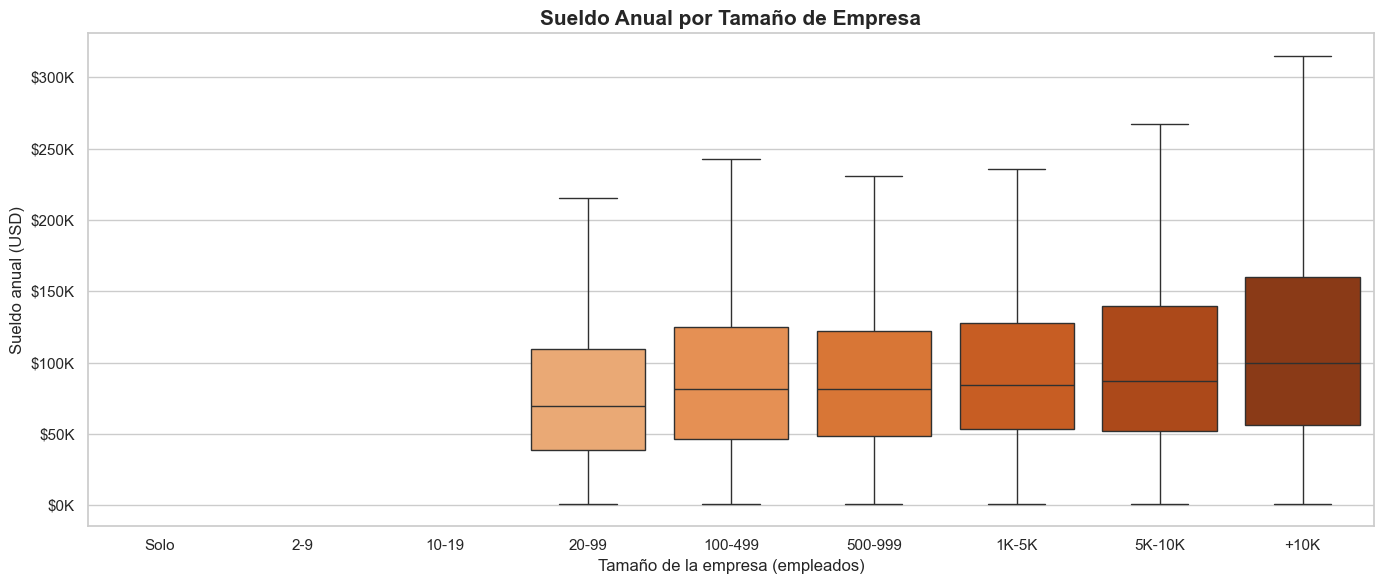

Outliers salariales (método IQR) en subconjunto df_bp3: 641  (3.9 %)


In [72]:
# ── Boxplot 3: Sueldo por tamaño de empresa ─────────────────────────────────
df_bp3 = df_sal[df_sal["OrgSize_short"].isin(ORGSIZE_ORDER)].copy()

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=df_bp3, x="OrgSize_short", y="ConvertedCompYearly",
    order=ORGSIZE_ORDER, palette="Oranges", showfliers=False, ax=ax
)

ax.set_title("Sueldo Anual por Tamaño de Empresa", fontsize=15, fontweight="bold")
ax.set_xlabel("Tamaño de la empresa (empleados)")
ax.set_ylabel("Sueldo anual (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
plt.tight_layout()
plt.savefig("box_orgsize.png", dpi=150, bbox_inches="tight")
plt.show()

# Detección de outliers con IQR
Q1, Q3 = df_bp3["ConvertedCompYearly"].quantile([0.25, 0.75])
IQR    = Q3 - Q1
n_out  = ((df_bp3["ConvertedCompYearly"] < Q1 - 1.5*IQR) |
           (df_bp3["ConvertedCompYearly"] > Q3 + 1.5*IQR)).sum()
print(f"Outliers salariales (método IQR) en subconjunto df_bp3: {n_out:,}  "
      f"({n_out/len(df_bp3)*100:.1f} %)")

---
### 4.4 Relación entre variables — Scatterplots

> Se usa una muestra aleatoria de 5 000 puntos para evitar sobreploteo,
  junto con una línea de tendencia lineal y el coeficiente de correlación de Pearson.

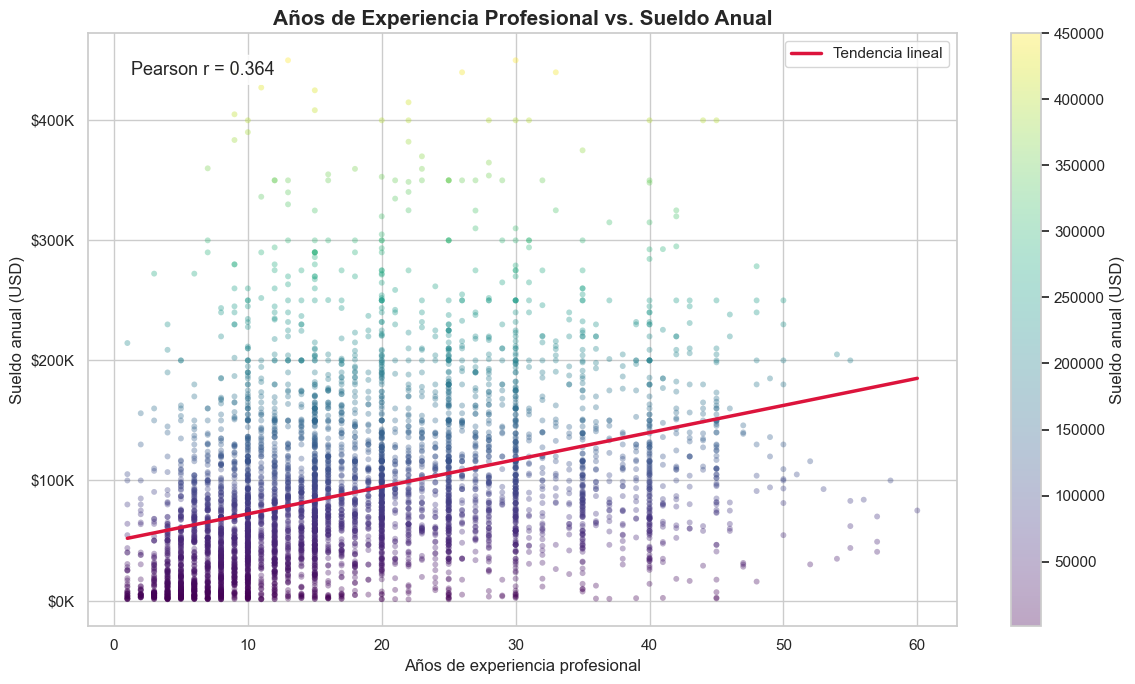

Correlación de Pearson (YearsCode vs Sueldo): 0.364
→ Correlación positiva moderada: a mayor experiencia, mayor sueldo.


In [73]:
# ── Scatterplot 1: Experiencia profesional vs. Sueldo ───────────────────────
df_sc1 = df_sal.dropna(subset=["YearsCode"]).sample(n=min(5_000, len(df_sal)), random_state=42)

fig, ax = plt.subplots(figsize=(12, 7))

sc = ax.scatter(
    df_sc1["YearsCode"], df_sc1["ConvertedCompYearly"],
    c=df_sc1["ConvertedCompYearly"], cmap="viridis",
    alpha=0.35, s=18, edgecolors="none"
)

# Línea de tendencia
m, b = np.polyfit(df_sc1["YearsCode"], df_sc1["ConvertedCompYearly"], 1)
xs   = np.linspace(df_sc1["YearsCode"].min(), df_sc1["YearsCode"].max(), 200)
ax.plot(xs, m*xs + b, color="crimson", lw=2.5, label="Tendencia lineal")

plt.colorbar(sc, ax=ax, label="Sueldo anual (USD)")
ax.set_title("Años de Experiencia Profesional vs. Sueldo Anual", fontsize=15, fontweight="bold")
ax.set_xlabel("Años de experiencia profesional")
ax.set_ylabel("Sueldo anual (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

r = df_sal.dropna(subset=["YearsCode"])[["YearsCode", "ConvertedCompYearly"]].corr().iloc[0, 1]
ax.text(0.05, 0.93, f"Pearson r = {r:.3f}", transform=ax.transAxes,
        fontsize=13, bbox=dict(boxstyle="round", fc="white", alpha=0.85))
ax.legend()
plt.tight_layout()
plt.savefig("scatter_exp_sal.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Correlación de Pearson (YearsCode vs Sueldo): {r:.3f}")
print("→ Correlación positiva moderada: a mayor experiencia, mayor sueldo.")

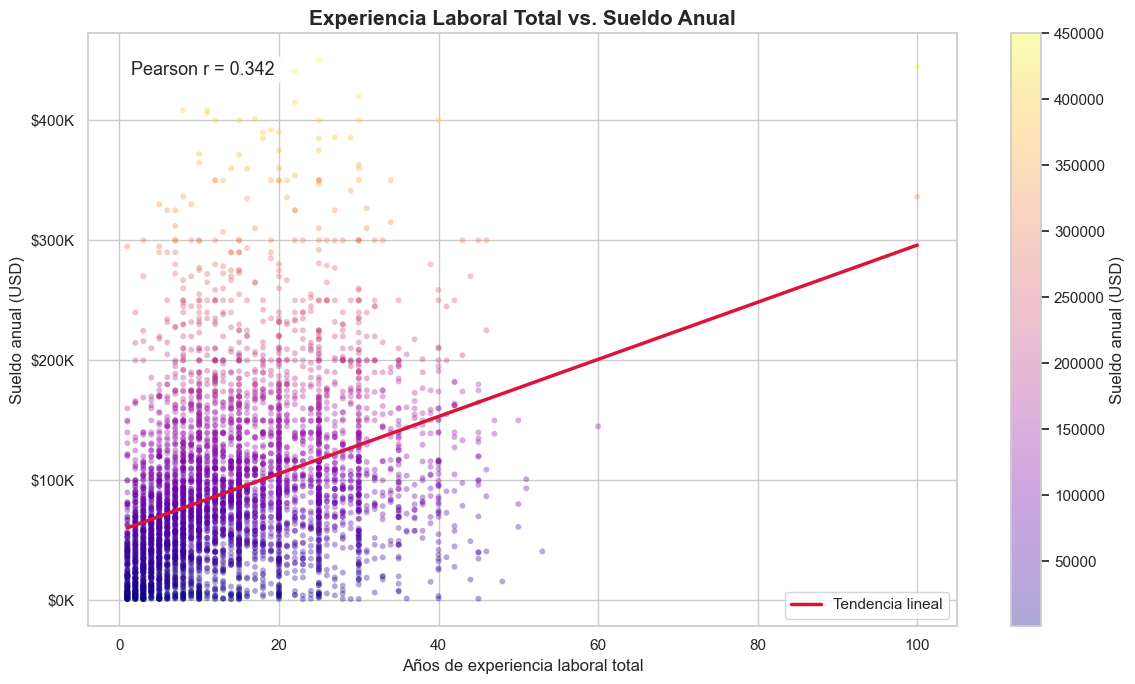

Correlación de Pearson (WorkExp vs Sueldo): 0.342


In [74]:
# ── Scatterplot 2: Experiencia laboral total vs. Sueldo ─────────────────────
df_sc2 = df_sal.dropna(subset=["WorkExp"]).sample(n=min(5_000, len(df_sal)), random_state=42)

fig, ax = plt.subplots(figsize=(12, 7))

sc2 = ax.scatter(
    df_sc2["WorkExp"], df_sc2["ConvertedCompYearly"],
    c=df_sc2["ConvertedCompYearly"], cmap="plasma",
    alpha=0.35, s=18, edgecolors="none"
)

m2, b2 = np.polyfit(df_sc2["WorkExp"], df_sc2["ConvertedCompYearly"], 1)
xs2    = np.linspace(df_sc2["WorkExp"].min(), df_sc2["WorkExp"].max(), 200)
ax.plot(xs2, m2*xs2 + b2, color="crimson", lw=2.5, label="Tendencia lineal")

plt.colorbar(sc2, ax=ax, label="Sueldo anual (USD)")
ax.set_title("Experiencia Laboral Total vs. Sueldo Anual", fontsize=15, fontweight="bold")
ax.set_xlabel("Años de experiencia laboral total")
ax.set_ylabel("Sueldo anual (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

r2 = df_sal.dropna(subset=["WorkExp"])[["WorkExp", "ConvertedCompYearly"]].corr().iloc[0, 1]
ax.text(0.05, 0.93, f"Pearson r = {r2:.3f}", transform=ax.transAxes,
        fontsize=13, bbox=dict(boxstyle="round", fc="white", alpha=0.85))
ax.legend()
plt.tight_layout()
plt.savefig("scatter_wexp_sal.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Correlación de Pearson (WorkExp vs Sueldo): {r2:.3f}")

---
### 4.5 Visualizaciones adicionales

#### A1 — Top 10 países por cantidad de participantes de la encuesta

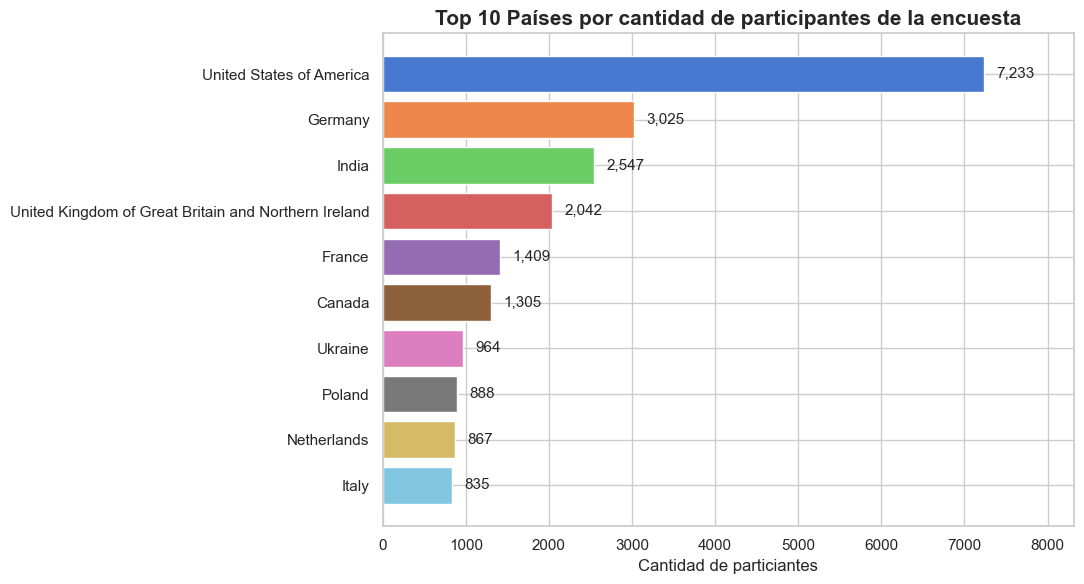

EE.UU. representa el 14.7 % de las respuestas.


In [75]:
# ── Adicional 1: Barras horizontales — Top 10 países ─────────────────────────
top10 = df["Country"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 6))
colors = sns.color_palette("muted", 10)
bars   = ax.barh(top10.index[::-1], top10.values[::-1], color=colors[::-1], edgecolor="white")

for bar, val in zip(bars, top10.values[::-1]):
    ax.text(bar.get_width() + 150, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", ha="left", fontsize=11)

ax.set_title("Top 10 Países por cantidad de participantes de la encuesta", fontsize=15, fontweight="bold")
ax.set_xlabel("Cantidad de particiantes")
ax.set_xlim(0, top10.max() * 1.15)
plt.tight_layout()
plt.savefig("bar_paises.png", dpi=150, bbox_inches="tight")
plt.show()

pct_us = top10["United States of America"] / len(df) * 100
print(f"EE.UU. representa el {pct_us:.1f} % de las respuestas.")

#### A2 — Salario mediano por tipo de desarrollador

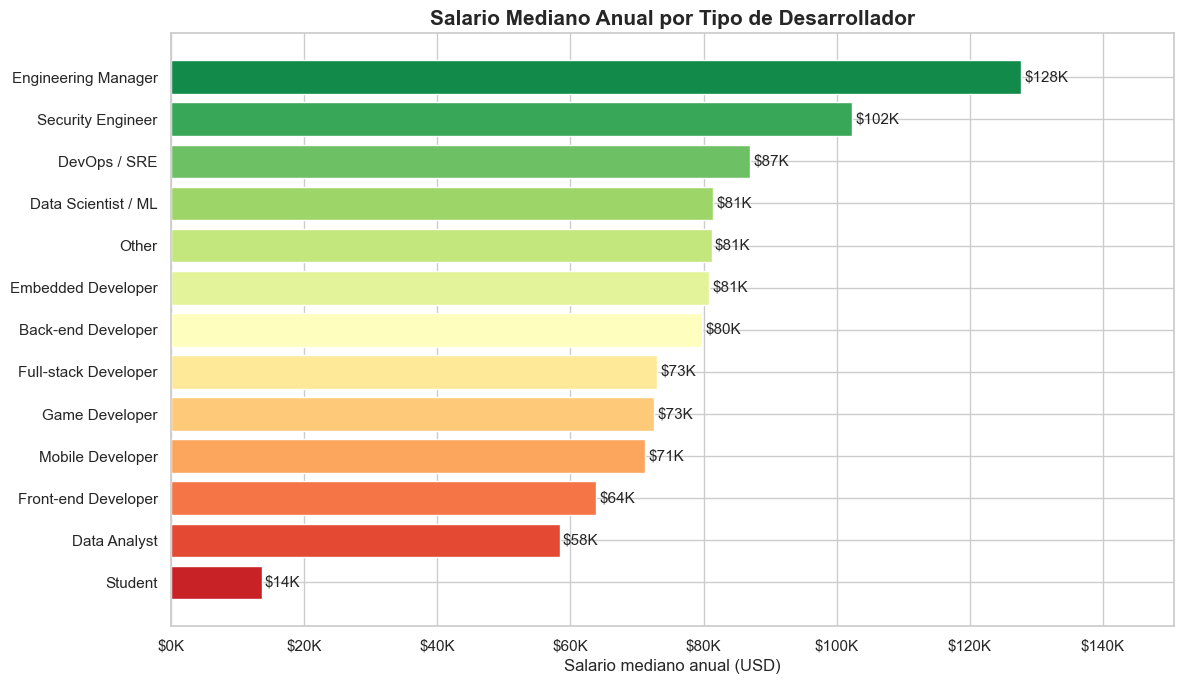

In [76]:
# ── Adicional 2: Barras — Salario mediano por rol ─────────────────────────────
devtype_stats = (
    df_sal[df_sal["DevType_simp"].notna()]
    .groupby("DevType_simp")["ConvertedCompYearly"]
    .agg(Mediana="median", n="count")
    .query("n >= 80")                        # Solo roles con suficientes respuestas
    .sort_values("Mediana", ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 7))
palette = sns.color_palette("RdYlGn", len(devtype_stats))
bars    = ax.barh(devtype_stats.index, devtype_stats["Mediana"],
                  color=palette, edgecolor="white")

for bar, val in zip(bars, devtype_stats["Mediana"]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f"${val/1000:.0f}K", va="center", ha="left", fontsize=11)

ax.set_title("Salario Mediano Anual por Tipo de Desarrollador", fontsize=15, fontweight="bold")
ax.set_xlabel("Salario mediano anual (USD)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
ax.set_xlim(0, devtype_stats["Mediana"].max() * 1.18)
plt.tight_layout()
plt.savefig("bar_devtype_sal.png", dpi=150, bbox_inches="tight")
plt.show()

#### A3 — Salario mediano según cantidad de años de experiencia profesional

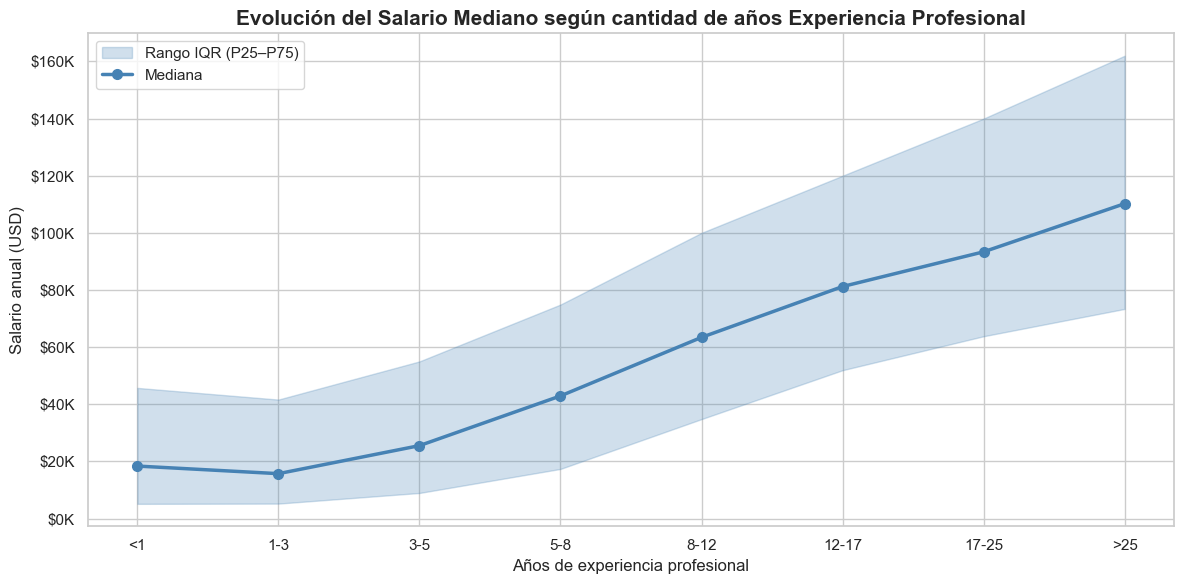

Salario mediano y cantidad de respuestas por cantidad de años:
Tramo_exp     mediana    n
       <1  USD 18,371  132
      1-3  USD 15,715  551
      3-5  USD 25,523 1327
      5-8  USD 42,925 2776
     8-12  USD 63,422 4174
    12-17  USD 81,210 4134
    17-25  USD 93,364 4848
      >25 USD 110,214 4876


In [77]:
# ── Adicional 3: Línea — Salario mediano por cantidad de años de experiencia ─────────────
df_tramos = df_sal.dropna(subset=["YearsCode"]).copy()
bins_exp   = [0, 1, 3, 5, 8, 12, 17, 25, 50]
labels_exp = ["<1", "1-3", "3-5", "5-8", "8-12", "12-17", "17-25", ">25"]
df_tramos["Tramo_exp"] = pd.cut(df_tramos["YearsCode"], bins=bins_exp, labels=labels_exp)

evolucion = df_tramos.groupby("Tramo_exp", observed=True)["ConvertedCompYearly"].agg(
    mediana="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75), n="count"
).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(range(len(evolucion)), evolucion["q25"], evolucion["q75"],
                alpha=0.25, color="steelblue", label="Rango IQR (P25–P75)")
ax.plot(range(len(evolucion)), evolucion["mediana"],
        marker="o", color="steelblue", lw=2.5, markersize=7, label="Mediana")

ax.set_xticks(range(len(evolucion)))
ax.set_xticklabels(evolucion["Tramo_exp"].astype(str))
ax.set_title("Evolución del Salario Mediano según cantidad de años Experiencia Profesional",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Años de experiencia profesional")
ax.set_ylabel("Salario anual (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
ax.legend()
plt.tight_layout()
plt.savefig("linea_exp_sal.png", dpi=150, bbox_inches="tight")
plt.show()

print("Salario mediano y cantidad de respuestas por cantidad de años:")
evolucion["mediana"] = evolucion["mediana"].apply(lambda x: f"USD {x:,.0f}")
print(evolucion[["Tramo_exp", "mediana", "n"]].to_string(index=False))

---
### 4.6 Correlaciones — Heatmap

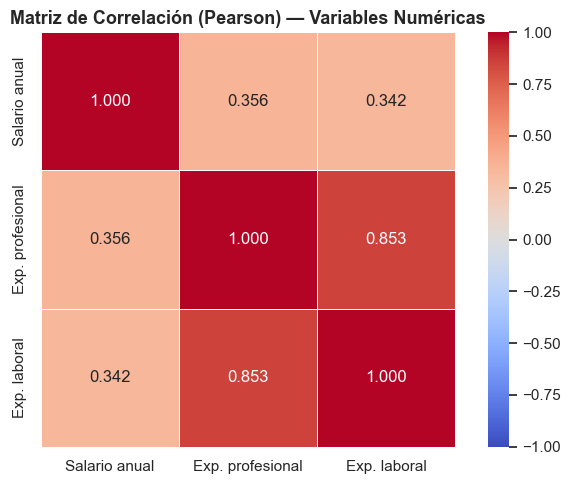

Correlación más fuerte: experiencia laboral total ↔ experiencia profesional
Ambas variables de experiencia tienen correlación positiva moderada con el salario.


In [78]:
# ── Heatmap de correlación ────────────────────────────────────────────────────
COLS_CORR = ["ConvertedCompYearly", "YearsCode", "WorkExp"]
LABELS_CORR = {
    "ConvertedCompYearly": "Salario anual",
    "YearsCode":        "Exp. profesional",
    "WorkExp":             "Exp. laboral",
}

corr_matrix = df_sal[COLS_CORR].dropna().corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_matrix, annot=True, fmt=".3f",
    cmap="coolwarm", vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    xticklabels=[LABELS_CORR[c] for c in COLS_CORR],
    yticklabels=[LABELS_CORR[c] for c in COLS_CORR],
    ax=ax
)
ax.set_title("Matriz de Correlación (Pearson) — Variables Numéricas",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("heatmap_corr.png", dpi=150, bbox_inches="tight")
plt.show()

print("Correlación más fuerte: experiencia laboral total ↔ experiencia profesional")
print("Ambas variables de experiencia tienen correlación positiva moderada con el salario.")

---
## 5. Respuesta a las hipótesis

Cada hipótesis se responde con métricas concretas y el gráfico de referencia.

### H1 — Experiencia profesional y salario

In [79]:
# ── H1: ¿Mayor experiencia → mayor salario? ──────────────────────────────────
df_h1 = df_sal.dropna(subset=["YearsCode"]).copy()
df_h1["Tramo"] = pd.cut(df_h1["YearsCode"],
                         bins=[0, 2, 5, 10, 20, 50],
                         labels=["0-2 años", "3-5 años", "6-10 años", "11-20 años", ">20 años"])

tabla_h1 = df_h1.groupby("Tramo", observed=True)["ConvertedCompYearly"].agg(
    Mediana="median", Media="mean", n="count"
)
tabla_h1["Mediana"] = tabla_h1["Mediana"].apply(lambda x: f"USD {x:,.0f}")
tabla_h1["Media"]   = tabla_h1["Media"].apply(lambda x: f"USD {x:,.0f}")

r_h1 = df_sal.dropna(subset=["YearsCode"])[["YearsCode","ConvertedCompYearly"]].corr().iloc[0,1]

print("Salario por tramo de experiencia profesional:")
print(tabla_h1.to_string())
print(f"\nCorrelación de Pearson: {r_h1:.3f}")
print()
print("   H1 CONFIRMADA — A mayor experiencia profesional, mayor salario mediano.")
print("   El incremento es sistemático en todos los tramos y la correlación es positiva.")

Salario por tramo de experiencia profesional:
                Mediana        Media     n
Tramo                                     
0-2 años     USD 12,470   USD 33,663   316
3-5 años     USD 23,484   USD 37,492  1694
6-10 años    USD 50,180   USD 61,696  5244
11-20 años   USD 81,685   USD 95,495  8310
>20 años    USD 105,577  USD 120,010  7254

Correlación de Pearson: 0.364

   H1 CONFIRMADA — A mayor experiencia profesional, mayor salario mediano.
   El incremento es sistemático en todos los tramos y la correlación es positiva.


### H2 — Modalidad de trabajo y salario

In [80]:
# ── H2: ¿Remoto → mayor salario? ─────────────────────────────────────────────
RMAP = {"In-person": "Presencial",
                 "Hybrid (some in-person, leans heavy to flexibility)": "1-2 días presenciales",
                 "Hybrid (some remote, leans heavy to in-person)": "3-4 días presenciales",
                 "Remote": "Remoto",
                 "Your choice (very flexible, you can come in when you want or just as needed)": "Completamente a elección"}

df_h2 = df_sal[df_sal["RemoteWork"].isin(RMAP)].copy()
df_h2["Modalidad"] = df_h2["RemoteWork"].map(RMAP)

tabla_h2 = df_h2.groupby("Modalidad")["ConvertedCompYearly"].agg(
    Mediana="median", Media="mean", n="count"
).loc[["Presencial", "1-2 días presenciales",  "3-4 días presenciales", "Remoto", "Completamente a elección"]]
tabla_h2["Mediana"] = tabla_h2["Mediana"].apply(lambda x: f"USD {x:,.0f}")
tabla_h2["Media"]   = tabla_h2["Media"].apply(lambda x: f"USD {x:,.0f}")

print("Salario por modalidad de trabajo:")
print(tabla_h2.to_string())
print()
print("   H2 CONFIRMADA — El trabajo remoto supera al presencial.")

Salario por modalidad de trabajo:
                             Mediana        Media     n
Modalidad                                              
Presencial                USD 47,566   USD 66,614  3053
1-2 días presenciales     USD 81,210   USD 90,619  3734
3-4 días presenciales     USD 73,375   USD 87,649  4078
Remoto                    USD 90,491  USD 104,595  6837
Completamente a elección  USD 76,570   USD 87,922  2665

   H2 CONFIRMADA — El trabajo remoto supera al presencial.


### H3 — Nivel educativo y salario

In [81]:
# ── H3: ¿Mayor educación → mayor salario? ────────────────────────────────────
df_h3 = df_sal[df_sal["EdLevel_short"].isin(EDLEVEL_ORDER)].copy()

tabla_h3 = df_h3.groupby("EdLevel_short", observed=True)["ConvertedCompYearly"].agg(
    Mediana="median", n="count"
).reindex(EDLEVEL_ORDER)
tabla_h3["Mediana"] = tabla_h3["Mediana"].apply(lambda x: f"USD {x:,.0f}" if pd.notna(x) else "N/D")

print("Salario mediano por nivel educativo (orden creciente):")
print(tabla_h3.to_string())
print()
print("   H3 PARCIALMENTE CONFIRMADA — La relación no es perfectamente monotónica.")
print("   Licenciatura y Maestría muestran salarios altos, pero 'Univ. sin título' a veces")
print("   supera a Tecnicatura, lo que sugiere que la experiencia práctica pesa tanto")
print("   o más que el título formal en la industria del software.")

Salario mediano por nivel educativo (orden creciente):
                     Mediana      n
EdLevel_short                      
Primaria          USD 64,408    106
Secundaria        USD 54,527   1144
Univ. sin título  USD 69,310   2737
Tecnicatura       USD 70,769    765
Licenciatura      USD 78,714  10022
Maestría          USD 81,210   6699
Doctorado / PhD   USD 88,171   1301

   H3 PARCIALMENTE CONFIRMADA — La relación no es perfectamente monotónica.
   Licenciatura y Maestría muestran salarios altos, pero 'Univ. sin título' a veces
   supera a Tecnicatura, lo que sugiere que la experiencia práctica pesa tanto
   o más que el título formal en la industria del software.


### H4 — Tamaño de empresa y salario

In [82]:
# ── H4: ¿Empresa más grande → mayor salario? ─────────────────────────────────
df_h4 = df_sal[df_sal["OrgSize_short"].isin(ORGSIZE_ORDER)].copy()

tabla_h4 = df_h4.groupby("OrgSize_short", observed=True)["ConvertedCompYearly"].agg(
    Mediana="median", n="count"
).reindex(ORGSIZE_ORDER)
tabla_h4["Mediana"] = tabla_h4["Mediana"].apply(lambda x: f"USD {x:,.0f}")

print("Salario mediano por tamaño de empresa:")
print(tabla_h4.to_string())
print()
print("   H4 CONFIRMADA — En términos generales, las empresas más grandes pagan más.")
print("   Las empresas de +10K empleados tienen la mediana salarial más alta.")
print("   Excepción: empresas muy pequeñas (solo o 2-9) a veces tienen outliers altos")
print("   por freelancers o fundadores con ingresos elevados.")

Salario mediano por tamaño de empresa:
                   Mediana       n
OrgSize_short                     
Solo               USD nan     NaN
2-9                USD nan     NaN
10-19              USD nan     NaN
20-99           USD 69,764  4153.0
100-499         USD 81,210  3915.0
500-999         USD 81,210  1544.0
1K-5K           USD 84,329  2669.0
5K-10K          USD 87,006  1016.0
+10K           USD 100,000  3064.0

   H4 CONFIRMADA — En términos generales, las empresas más grandes pagan más.
   Las empresas de +10K empleados tienen la mediana salarial más alta.
   Excepción: empresas muy pequeñas (solo o 2-9) a veces tienen outliers altos
   por freelancers o fundadores con ingresos elevados.


### H5 — Tipo de desarrollador y salario

In [83]:
# ── H5: ¿El rol determina diferencias salariales? ────────────────────────────
df_h5 = df_sal[df_sal["DevType_simp"].notna()].copy()

tabla_h5 = df_h5.groupby("DevType_simp")["ConvertedCompYearly"].agg(
    Mediana="median", n="count"
).query("n >= 80").sort_values("Mediana", ascending=False)
tabla_h5["Mediana"] = tabla_h5["Mediana"].apply(lambda x: f"USD {x:,.0f}")

print("Salario mediano por tipo de desarrollador (ranking descendente):")
print(tabla_h5.to_string())
print()
print("   H5 CONFIRMADA — Existen diferencias salariales significativas entre roles.")
print("   Engineering Manager y Security Engineer lideran el ranking salarial.")
print("   Data Scientist/ML y DevOps/SRE también aparece en los primeros puestos.")
print("   Front-end y Data Analyst se ubican en los niveles más bajos.")

Salario mediano por tipo de desarrollador (ranking descendente):
                          Mediana     n
DevType_simp                           
Engineering Manager   USD 127,677   691
Security Engineer     USD 102,316   178
DevOps / SRE           USD 87,011   679
Data Scientist / ML    USD 81,377   335
Other                  USD 81,210  6835
Embedded Developer     USD 80,766   746
Back-end Developer     USD 79,818  3801
Full-stack Developer   USD 72,958  7204
Game Developer         USD 72,606   194
Mobile Developer       USD 71,180   732
Front-end Developer    USD 63,808  1081
Data Analyst           USD 58,367   177
Student                USD 13,614   328

   H5 CONFIRMADA — Existen diferencias salariales significativas entre roles.
   Engineering Manager y Security Engineer lideran el ranking salarial.
   Data Scientist/ML y DevOps/SRE también aparece en los primeros puestos.
   Front-end y Data Analyst se ubican en los niveles más bajos.


---
## 6. Conclusiones finales

### Hallazgos principales

A partir del análisis exploratorio de ~49.000 respuestas de desarrolladores globales
en la encuesta de Stack Overflow 2025, se obtuvieron los siguientes hallazgos:

1. **Distribución salarial sesgada** — Los salarios tienen una distribución con fuerte
   asimetría positiva. La mayoría de los desarrolladores gana menos de USD 100K/año,
   pero un segmento reduce la representatividad de la media como medida central;
   la **mediana** es el estadístico más adecuado para describir el ingreso típico.

2. **La experiencia profesional importa** — La correlación positiva entre
   años de experiencia y salario es clara y consistente en todos los tramos analizados.
   Pasar de 0-2 a 3-5 años de experiencia ya representa un salto salarial relevante.

3. **Trabajo remoto casi que garantiza mayor pago** — Contrariamente a la creencia
   popular, el trabajo híbrido muestra medianas salariales levemente inferiores al
   remoto puro, pero el trabajo remoto sigue liderando el ranking.

4. **Educación formal no es determinante absoluto** — Si bien los niveles
   altos (Maestría, Doctorado) se asocian a salarios mayores, la diferencia con
   Licenciatura es moderada. Desarrolladores sin título universitario completo pueden
   superar en ingresos a quienes tienen tecnicatura, evidenciando que la experiencia
   práctica es muy valorada en la industria tech.

5. **Empresas grandes pagan más** — La relación entre tamaño organizacional
   y salario es positiva y robusta. Las empresas de más de 10 000 empleados presentan
   la mediana salarial más alta del conjunto.

6. **El rol define el salario** — Engineering Manager, DevOps/SRE y
   Security Engineer lideran el ranking. La diferencia entre el rol mejor y peor pagado
   puede superar los USD 40 000 anuales en mediana.

### Limitaciones del análisis

- Los salarios están reportados en USD, pero la muestra está
  sesgada hacia EE.UU. (> 15 % de las respuestas), lo que infla los valores globales.
- El ~70 % de los encuestados no reportó su salario, lo cual puede introducir sesgo
  de no respuesta (quienes responden podrían ser los que ganan más o menos).
- `DevType` es multi-valor y la simplificación a un único rol puede no capturar
  perfiles mixtos (ej.: un full-stack que también hace DevOps).